In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from IPython.display import display
import ipywidgets as widgets

In [2]:
uploaded_1 = files.upload()
image_name_1 = next(iter(uploaded_1))
class_vision_image_path = '/content/' + image_name_1
print('Selected Image 1:', class_vision_image_path)

Saving class.vision.jpg to class.vision.jpg
Selected Image 1: /content/class.vision.jpg


In [10]:
uploaded_2 = files.upload()
image_name_2 = next(iter(uploaded_2))
wolf_image_path = '/content/' + image_name_2
print('Selected Image 2:', wolf_image_path)

Saving Practice Picture.jpg to Practice Picture (1).jpg
Selected Image 2: /content/Practice Picture (1).jpg


In [12]:
scr1 = cv2.imread(class_vision_image_path)
scr2 = cv2.imread(wolf_image_path)

if scr1 is None or scr2 is None:
    raise ValueError('One Of The Images Could Not Be Read')

if scr1.shape[:2] != scr2.shape[:2]:
    scr2 = cv2.resize(scr2, (scr1.shape[1], scr1.shape[0]))
    print('scr2 Was Resized To Match scr1')

print('scr1 Shape:', scr1.shape)
print('scr2 Shape:', scr2.shape)

scr2 Was Resized To Match scr1
scr1 Shape: (150, 300, 3)
scr2 Shape: (150, 300, 3)


In [20]:
alpha_slider_max = 100

def on_trackbar(val):
  alpha = val / alpha_slider_max
  beta = 1.0 - alpha
  dst = cv2.addWeighted(scr1, alpha, scr2, beta, 0.0)

  plt.figure(figsize=(15, 5))
  plt.subplot(131)
  plt.imshow(scr1[..., ::-1])
  plt.title('Class Vision')
  plt.axis('off')

  plt.subplot(132)
  plt.imshow(scr2[..., ::-1])
  plt.title('Wolf')
  plt.axis('off')

  plt.subplot(133)
  plt.imshow(dst[..., ::-1])
  plt.title('Blend')
  plt.axis('off')

  plt.show()

alpha_widget = widgets.widgets.IntSlider(
    value=0,
    min=0,
    max=alpha_slider_max,
    step=1,
    description='Alpha * 100',
    continuous_update=False,
)

widgets.interact(on_trackbar, val=alpha_widget)

interactive(children=(IntSlider(value=0, continuous_update=False, description='Alpha * 100'), Output()), _dom_…

<function __main__.on_trackbar(val)>

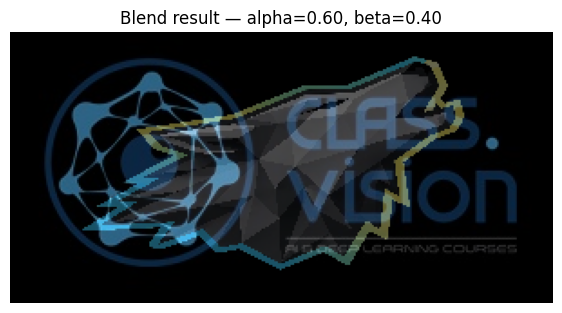

alpha:0.6


In [17]:
alpha_value = 60
alpha = alpha_value / alpha_slider_max
beta = 1.0 - alpha
dst = cv2.addWeighted(scr1, alpha, scr2, beta, 0.0)

plt.figure(figsize=(7, 5))
plt.imshow(dst[..., ::-1])
plt.title(f'Blend result — alpha={alpha:.2f}, beta={beta:.2f}')
plt.axis('off')
plt.show()

print(f'alpha:{alpha}')

In [19]:
red_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=255,
    step=1,
    description='Red')

green_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=255,
    step=1,
    description='Green')

blue_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=255,
    step=1,
    description='Blue')

switch_widget = widgets.widgets.ToggleButton(
    value=True,
    description='Enable Color',
    disabled=False,
    button_style='',
    tooltip='Click to toggle color',
    icon='check'
)

output_area = widgets.Output()

def update_color_image(change=None):
  with output_area:
    output_area.clear_output(wait=True)
    color_image = np.zeros((300, 512, 3), dtype=np.uint8)
    if switch_widget.value:
      color_image[:] = [blue_slider.value, green_slider.value, red_slider.value]

    plt.figure(figsize=(10, 4))
    plt.imshow(color_image[..., ::-1])
    state = 'ON' if switch_widget.value else 'OFF'
    plt.title(f'Color Trackbars — {state} | R={red_slider.value}, G={green_slider.value}, B={blue_slider.value}')
    plt.axis('off')
    plt.show()

for widget in [red_slider, green_slider, blue_slider, switch_widget]:
  widget.observe(update_color_image, names='value')

display(widgets.VBox([red_slider, green_slider, blue_slider, switch_widget, output_area]))

update_color_image()